# Step 1: Gene Prediction Evaluation

This notebook evaluates the structural concordance of gene predictions from various prokaryotic annotation tools (Prokka, Bakta, PGAP, eggNOG) against the NCBI RefSeq ground truth. 

It standardizes the GFF outputs, calculates performance metrics (Precision, Recall, F1-Score), visualizes intersections using UpSet plots, and exports the concordant CDS sets for downstream functional analysis.

In [1]:
import sys
import os
import urllib.request
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(".."))

from prokaryotic.gene_prediction import (
    clean_prokka_gff,
    load_gff,
    standardize_gff,
    calculate_structural_metrics,
    plot_concordance_upset,
    export_concordant_cds,
)

TOOLS_TO_EVALUATE = ["Prokka", "Bakta", "PGAP", "eggNOG"]
UPSET_ORDER = ["Reference", "PGAP", "Bakta", "Prokka", "eggNOG"]

## 1. Define Organisms and Download Reference Data

We define a dictionary mapping each organism to its respective NCBI RefSeq GFF and GBFF URLs. The loop will automatically download, extract, and organize the reference files into their respective data directories.

In [2]:
reference_genomes = {
    "bacillus": {
        "gff_url": "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gff.gz",
        "gbff_url": "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gbff.gz",
    },
    "e_coli": {
        "gff_url": "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gff.gz",
        "gbff_url": "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz",
    },
}


def download_and_extract(url, output_dir, final_filename):
    """Helper function to download and gunzip files."""
    gz_path = os.path.join(output_dir, "temp.gz")
    final_path = os.path.join(output_dir, final_filename)

    if not os.path.exists(final_path):
        print(f"Downloading {final_filename}...")
        urllib.request.urlretrieve(url, gz_path)
        os.system(f"gunzip -c {gz_path} > {final_path}")
        os.remove(gz_path)


for org, urls in reference_genomes.items():
    data_dir = f"{org}_data"
    os.makedirs(data_dir, exist_ok=True)

    download_and_extract(urls["gff_url"], data_dir, f"{org}_genbank.gff")
    download_and_extract(urls["gbff_url"], data_dir, f"{org}_genbank.gbff")

## 2. Process, Evaluate, and Export

Iterate through each organism to clean the Prokka GFF, standardize all tool outputs into a unified format, generate concordance plots, calculate F1 metrics, and export the true positive CDS matches.

  Processing: BACILLUS


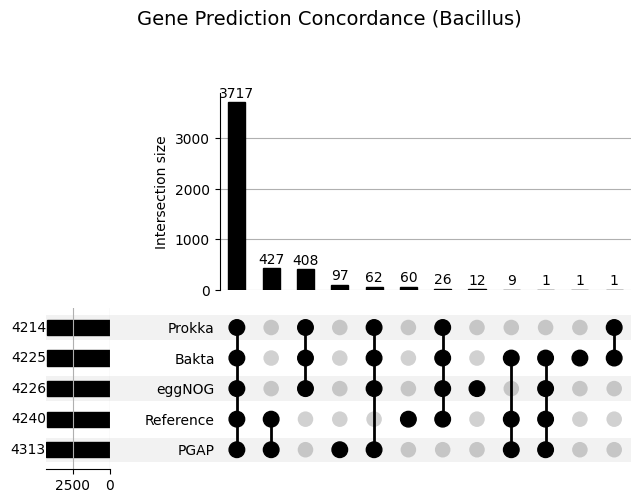

Metrics (Bacillus)


,Annotation Tool,Exact Matches (TP),Spurious/Shifted (FP),Missed Genes (FN),Precision,Recall,F1-Score
0,PGAP,4154,159,86,0.963100,0.979700,0.971400
1,Bakta,3753,472,487,0.888300,0.885100,0.886700
2,Prokka,3743,471,497,0.888200,0.882800,0.885500
3,eggNOG,3744,482,496,0.885900,0.883000,0.884500


-> Exported 3717 concordant CDS records to bacillus_data/bacillus_concordant_CDS.csv
-> Exported 4240 all CDS records to bacillus_data/bacillus_all_CDS.csv
  Processing: E_COLI


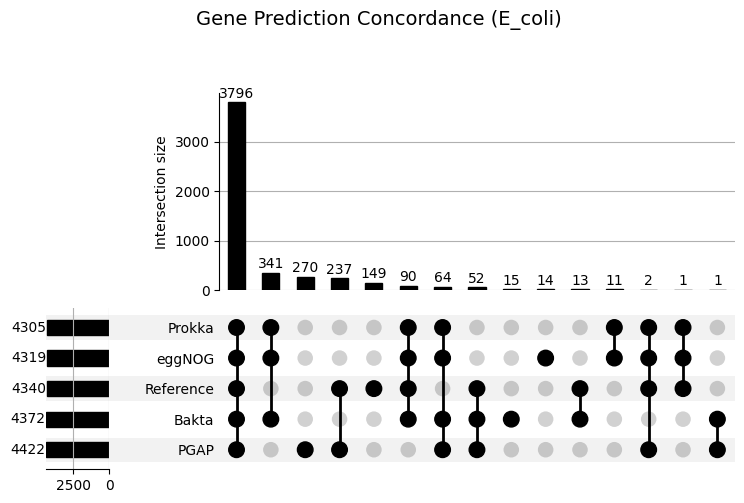

Metrics (E_coli)


,Annotation Tool,Exact Matches (TP),Spurious/Shifted (FP),Missed Genes (FN),Precision,Recall,F1-Score
0,PGAP,4087,335,253,0.924200,0.941700,0.932900
1,Bakta,3951,421,389,0.903700,0.910400,0.907000
2,Prokka,3889,416,451,0.903400,0.896100,0.899700
3,eggNOG,3889,430,451,0.900400,0.896100,0.898300


-> Exported 3796 concordant CDS records to e_coli_data/e_coli_concordant_CDS.csv
-> Exported 4340 all CDS records to e_coli_data/e_coli_all_CDS.csv


In [3]:
all_metrics = {}

for org in reference_genomes.keys():
    print(f"  Processing: {org.upper()}")

    PROKKA_RAW = f"../results/prokka/{org}_prokka/{org}.gff"
    PROKKA_CLEAN = f"{org}_data/{org}_prokka_cleaned.gff"
    PGAP_PATH = f"../results/pgap/{org}_pgap/annot.gff"
    BAKTA_PATH = f"../results/bakta/{org}_bakta/{org}.gff3"
    EGGNOG_PATH = f"../results/eggnog/{org}_eggnog/{org}.emapper.decorated.gff"
    GENBANK_PATH = f"{org}_data/{org}_genbank.gff"
    EXPORT_CSV = f"{org}_data/{org}_concordant_CDS.csv"
    ALL_CSV = f"{org}_data/{org}_all_CDS.csv"

    clean_prokka_gff(PROKKA_RAW, PROKKA_CLEAN)

    dfs = [
        load_gff(EGGNOG_PATH, "eggNOG"),
        load_gff(BAKTA_PATH, "Bakta"),
        load_gff(PROKKA_CLEAN, "Prokka"),
        load_gff(PGAP_PATH, "PGAP"),
        load_gff(GENBANK_PATH, "Reference"),
    ]

    standardized_dfs = []
    for df in dfs:
        if df["Source"].iloc[0] == "eggNOG":
            standardized_dfs.append(standardize_gff(df, is_eggnog=True))
        else:
            standardized_dfs.append(standardize_gff(df))

    all_gffs = pd.concat(standardized_dfs, ignore_index=True)

    plot_concordance_upset(
        all_gffs_df=all_gffs,
        tools_order=UPSET_ORDER,
        title=f"Gene Prediction Concordance ({org.capitalize()})",
        save_path=f"{org}_data/{org}_gene_prediction.png",
    )

    print(f"Metrics ({org.capitalize()})")
    df_metrics = calculate_structural_metrics(all_gffs, tools=TOOLS_TO_EVALUATE)

    all_metrics[org] = df_metrics

    display(
        df_metrics.style.background_gradient(
            cmap="Blues", subset=["F1-Score", "Precision", "Recall"]
        )
    )

    tp_df = export_concordant_cds(all_gffs, TOOLS_TO_EVALUATE, "Reference", EXPORT_CSV)
    print(f"-> Exported {len(tp_df)} concordant CDS records to {EXPORT_CSV}")
    all_df = export_concordant_cds(all_gffs, TOOLS_TO_EVALUATE, "Reference", ALL_CSV, concordant_only=False)
    print(f"-> Exported {len(all_df)} all CDS records to {ALL_CSV}")